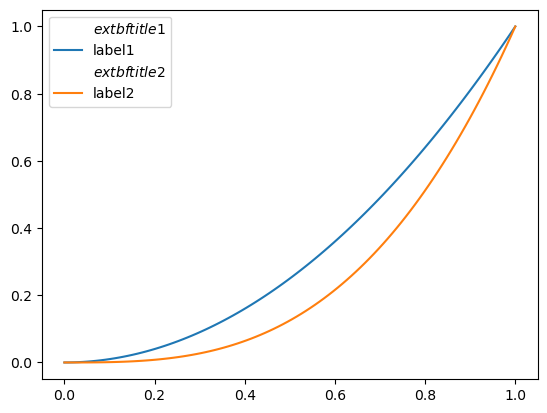

In [3]:
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 1, 100)

# the comma is to get just the first element of the list returned
plot1, = plt.plot(x, x**2) 
plot2, = plt.plot(x, x**3)

title_proxy = Rectangle((0,0), 0, 0, color='w')

plt.legend([title_proxy, plot1, title_proxy, plot2], 
           ["$\textbf{title1}$", "label1","$\textbf{title2}$", "label2"])
plt.show()

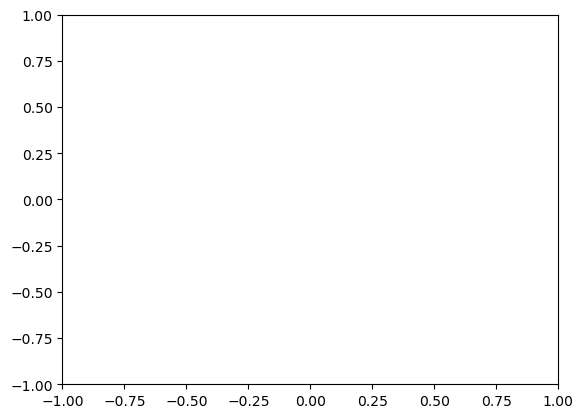

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots()

# Create a rectangle with no size and white color
rect = Rectangle((0, 0), 0, 0, color='w')

# Add the rectangle to the plot
ax.add_patch(rect)

# Set the limits of the plot
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)

plt.show()

10000


[Warning] The CPU supports AVX2 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports AVX but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSE4.2 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSE4.1 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSSE3 but the compiler does not.  Can you try another compiler?


8036
2771
1222
289
69
18


/tmp/ipykernel_8762/447637127.py:170: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#controlling-the-legend-entries
  plt.legend(legend_list, legend_labels) # loc='center left', bbox_to_anchor=(1, 0.5))


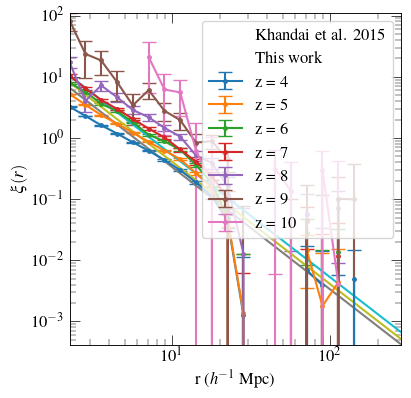

In [5]:
# I want to find the two point correlation function in each of the simulation box. 

import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt
# Import the cosmology
from astropy.cosmology import FlatLambdaCDM
# Import the DD function from Corrfunc
from Corrfunc.theory.DD import DD
from matplotlib.patches import Rectangle
from pandas import DataFrame

plt.style.use('MNRAS_Style.mplstyle')

# Define the cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Define the reduced Hubble constant
h = 0.7

# Define the path to data directory
DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/"


file_paths = ['/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_034.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_029.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_026.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_024.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_020.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_019.txt',
              '/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/bhprops_018.txt']

redshifts = np.array([4, 5, 6, 7, 8, 9, 10])

corrfunc_data = []

for i,file_path in enumerate(file_paths):
    # Load the data from the file
    data = np.loadtxt(file_path)
    
    # Extract the x, y, and z coordinates
    x_coordinates = data[:, 1]
    y_coordinates = data[:, 2]
    z_coordinates = data[:, 3]

    # Define the number of black holes to choose for the subset
    num_black_holes = 100000

    # randomly draw num_black_holes from the bh_coordinates
    if num_black_holes > x_coordinates.shape[0]:
        num_black_holes = x_coordinates.shape[0]
    random_indices = np.random.choice(x_coordinates.shape[0], num_black_holes, replace=False)

    bh_pos_x = x_coordinates[random_indices]/1000 # Convert to h^-1 Mpc
    bh_pos_y = y_coordinates[random_indices]/1000 # Convert to h^-1 Mpc
    bh_pos_z = z_coordinates[random_indices]/1000 # Convert to h^-1 Mpc
    print(len(bh_pos_x), flush=True)

    # Now I want to calculate the correlation function using the selected black holes and compare it with the correlation function using all black holes.
    # Full balck holes correlation function.

    min_x = 0
    max_x = 100 # h^-1 Mpc. Here x_coords, y_coords, z_coords are in h^-1 Mpc unlike the black holes coordinates directly from the MBII data.
    min_y = 0
    max_y = 100
    min_z = 0
    max_z = 100

    mult = 10 ## Number of random points used as a multiple of number of data points

    n_D = len(bh_pos_x)
    n_rand = mult * n_D
    rand_x = np.random.uniform(min_x, max_x, n_rand)
    rand_y = np.random.uniform(min_y, max_y, n_rand)
    rand_z = np.random.uniform(min_z, max_z, n_rand)

    bins = np.logspace(start=np.log10(1.9868), stop=np.log10(314.915), num=23) #np.arange(0.01, 100, bin_size)
    bin_mids = (bins[0:-1] + bins[1:])/2

    result_DD = DD(autocorr=1, nthreads=1, binfile=bins, X1 = bh_pos_x, Y1 = bh_pos_y, Z1 = bh_pos_z, periodic=False)
    result_RR = DD(autocorr=1, nthreads=1, binfile=bins, X1 = rand_x, Y1 = rand_y, Z1 = rand_z, periodic=False)
    result_DR = DD(autocorr=0, nthreads=1, binfile=bins, X1 = bh_pos_x, Y1 = bh_pos_y, Z1 = bh_pos_z, X2 = rand_x, Y2 = rand_y, Z2 = rand_z, periodic=False)

    DD_norm = (n_D * (n_D - 1))/2
    RR_norm = (n_rand * (n_rand - 1))/2
    DR_norm = n_D * n_rand

    DD_count = result_DD['npairs']/2
    RR_count = result_RR['npairs']/2
    DR_count = result_DR['npairs']

    nil_pos = np.where(DD_count * RR_count * DR_count == 0)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        LandSzal2pcf = (DD_count/DD_norm - 2 * DR_count/DR_norm + RR_count/RR_norm)/(RR_count/RR_norm)

    LandSzal2pcf = ma.array(LandSzal2pcf)
    LandSzal2pcf[nil_pos] = ma.masked

    with np.errstate(divide='ignore', invalid='ignore'):
        pois_err = (1 + LandSzal2pcf)/np.sqrt(np.minimum(DD_count, n_D))

    pois_err = ma.array(pois_err)
    pois_err[nil_pos] = ma.masked

    df = DataFrame({"r min":bins[0:-1], "r max":bins[1:], "DD count":DD_count, "DR count":DR_count, "RR count": RR_count, "Landy Szalay":LandSzal2pcf, "Pois Error":pois_err})

    #Save the data to a file
    df.to_csv(DATA_DIRECTORY + 'MBII_corrfunc_z{}.csv'.format(redshifts[i]), index=False)

    corrfunc_data.append(df)

# Plot the correlation functions    

plt.style.use('MNRAS_Style.mplstyle')

# Find the midpoint of each bin, as r_mid = (r_min + r_max) / 2
for i in range(len(redshifts)):
    corrfunc_data[i]['r mid'] = (corrfunc_data[i]['r min'] + corrfunc_data[i]['r max']) / 2

# Make an array to store the plot objects
plot_objects = np.zeros(len(redshifts), dtype=object)   

# Plot all the correlation functions
for i in range(len(redshifts)):
    plot_objects[i] = plt.errorbar(corrfunc_data[i]['r mid'][:-3], corrfunc_data[i]['Landy Szalay'][:-3], yerr=corrfunc_data[i]['Pois Error'][:-3], fmt='.-', markersize=5, capsize=5)

plt.ylabel(r'$\xi(r)$')
plt.xlabel(r'r ($h^{-1}$ Mpc)')
# plt.ylim(-0.5, 10)
# plt.xlim(0, 150)
plt.xscale('log')
plt.yscale('log')

Khandai_DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/"
temp_rmid = corrfunc_data[0]['r mid']

# Now also plot the correlation function from khandai et al. 2015 as power laws
MBII_fig25_filename = "Khandai_fig25_data.csv"
MBII_fig25 = np.loadtxt(Khandai_DATA_DIRECTORY + MBII_fig25_filename, skiprows=1, delimiter=',')

MBII_fig25_z = MBII_fig25[:, 0]
MBII_fig25_r0 = MBII_fig25[:, 1]

MBII_gamma = 2.0

# Make another array to store the plot objects
plot_objects_khandai = np.zeros(len(MBII_fig25_z[5:]), dtype=object)

for i in range(len(MBII_fig25_z[5:])):
    plot_objects_khandai[i], = plt.plot(temp_rmid, (temp_rmid/MBII_fig25_r0[i+5])**(-MBII_gamma))

# Make title proxy
title_proxy = Rectangle((0,0), 0, 0, color='w')

# Make a list of the following form: [title_proxy, plot_objects_khandai[0], plot_objects_khandai[1], ..., plot_objects_khandai[n], title_proxy, plot_objects[0], plot_objects[1], ..., plot_objects[n]]
legend_list = [title_proxy]
legend_list.extend(plot_objects_khandai)
legend_list.append(title_proxy)
legend_list.extend(plot_objects)

# Make a list to hold the labels for the legend like: ['Khandai et al. 2015', 'z = 4', ... , 'z = 6', 'This work', 'z = 4', ... , 'z = 10']
legend_labels = ['Khandai et al. 2015']
legend_labels.extend(['z = {}'.format(np.round(MBII_fig25_z[i+5])) for i in range(len(MBII_fig25_z[5:]))])
legend_labels.append('This work')
legend_labels.extend(['z = {}'.format(redshifts[i]) for i in range(len(redshifts))])

# give legends outside the plots
plt.legend(legend_list, legend_labels, loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(visible=False)
plt.gca().set_box_aspect(1)

# Save the plot as a pdf file
PLOT_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Plots/"

plt.savefig(PLOT_DIRECTORY + 'MBII_corrfunc.pdf')

plt.show()

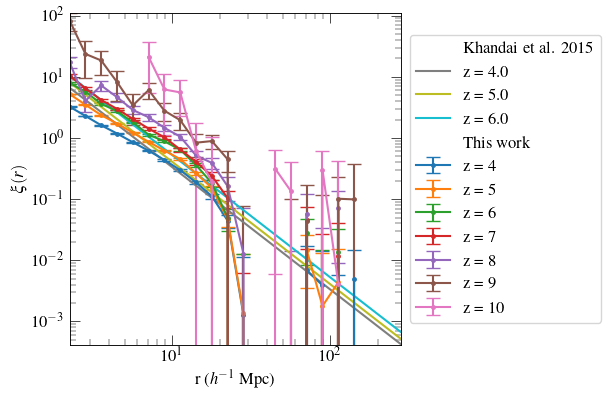

In [11]:
# Plot the correlation functions    

plt.style.use('MNRAS_Style.mplstyle')

# Find the midpoint of each bin, as r_mid = (r_min + r_max) / 2
for i in range(len(redshifts)):
    corrfunc_data[i]['r mid'] = (corrfunc_data[i]['r min'] + corrfunc_data[i]['r max']) / 2

# Make an array to store the plot objects
plot_objects = np.zeros(len(redshifts), dtype=object)   

# Plot all the correlation functions
for i in range(len(redshifts)):
    plot_objects[i] = plt.errorbar(corrfunc_data[i]['r mid'][:-3], corrfunc_data[i]['Landy Szalay'][:-3], yerr=corrfunc_data[i]['Pois Error'][:-3], fmt='.-', markersize=5, capsize=5)

plt.ylabel(r'$\xi(r)$')
plt.xlabel(r'r ($h^{-1}$ Mpc)')
# plt.ylim(-0.5, 10)
# plt.xlim(0, 150)
plt.xscale('log')
plt.yscale('log')

Khandai_DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/"
temp_rmid = corrfunc_data[0]['r mid']

# Now also plot the correlation function from khandai et al. 2015 as power laws
MBII_fig25_filename = "Khandai_fig25_data.csv"
MBII_fig25 = np.loadtxt(Khandai_DATA_DIRECTORY + MBII_fig25_filename, skiprows=1, delimiter=',')

MBII_fig25_z = MBII_fig25[:, 0]
MBII_fig25_r0 = MBII_fig25[:, 1]

MBII_gamma = 2.0

# Make another array to store the plot objects
plot_objects_khandai = np.zeros(len(MBII_fig25_z[5:]), dtype=object)

for i in range(len(MBII_fig25_z[5:])):
    plot_objects_khandai[i], = plt.plot(temp_rmid, (temp_rmid/MBII_fig25_r0[i+5])**(-MBII_gamma))

# Make title proxy
title_proxy = Rectangle((0,0), 0, 0, color='w')

# Make a list of the following form: [title_proxy, plot_objects_khandai[0], plot_objects_khandai[1], ..., plot_objects_khandai[n], title_proxy, plot_objects[0], plot_objects[1], ..., plot_objects[n]]
legend_list = [title_proxy]
legend_list.extend(plot_objects_khandai)
legend_list.append(title_proxy)
legend_list.extend(plot_objects)

# Make a list to hold the labels for the legend like: ['Khandai et al. 2015', 'z = 4', ... , 'z = 6', 'This work', 'z = 4', ... , 'z = 10']
legend_labels = ['Khandai et al. 2015']
legend_labels.extend(['z = {}'.format(np.round(MBII_fig25_z[i+5])) for i in range(len(MBII_fig25_z[5:]))])
legend_labels.append('This work')
legend_labels.extend(['z = {}'.format(redshifts[i]) for i in range(len(redshifts))])

# give legends outside the plots
plt.legend(legend_list, legend_labels, loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(visible=False)
plt.gca().set_box_aspect(1)

# Save the plot as a pdf file
PLOT_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Plots/"

plt.savefig(PLOT_DIRECTORY + 'MBII_corrfunc.pdf')

plt.show()

In [7]:


# Plot the correlation function
plt.style.use('MNRAS_Style.mplstyle')
for i in range(len(redshifts)):
    corrfunc_data[i]['r mid'] = (corrfunc_data[i]['r min'] + corrfunc_data[i]['r max'])/2
    plt.errorbar(corrfunc_data[i]['r mid'], corrfunc_data[i]['Landy Szalay'], yerr=corrfunc_data[i]['Pois Error'], fmt='.-', markersize=5, capsize=5, label='z = {}'.format(redshifts[i]))

plt.ylabel(r'$\xi(r)$')
plt.xlabel(r'r ($h^{-1}$ Mpc)')
# plt.ylim(-0.5, 10)
# plt.xlim(0, 150)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.xscale('log')
plt.yscale('log')
plt.grid(visible=False)
plt.gca().set_box_aspect(1)

# Save this plot as a pdf to Plot directory
plt.savefig(PLOT_DIRECTORY + 'MBII_lc_corrfunc.pdf')

 <ErrorbarContainer object of 3 artists>,
 <ErrorbarContainer object of 3 artists>,
 <ErrorbarContainer object of 3 artists>,
 <ErrorbarContainer object of 3 artists>,
 <ErrorbarContainer object of 3 artists>,
 <ErrorbarContainer object of 3 artists>,
 <ErrorbarContainer object of 3 artists>]

0


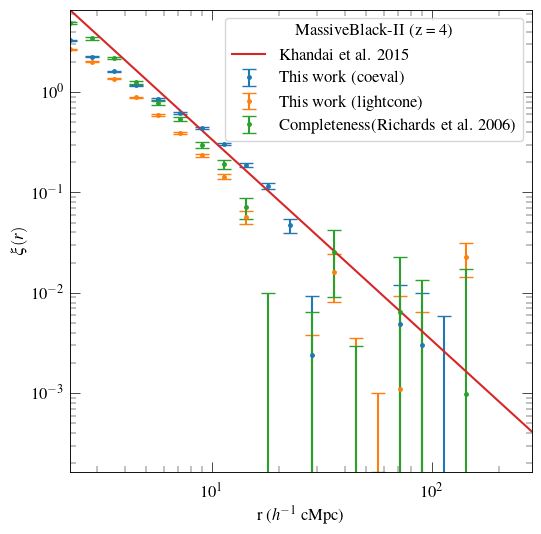

In [5]:
# plot the correlation function from MBII_corrfunc_z{}.csv files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('MNRAS_Style.mplstyle')

# Define the path to data directory
DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/MBIIbhIncompOverlf/"

# Define the path to Plot directory
PLOT_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Plots/"

# Define the redshifts
redshifts = np.array([4])

# Load the correlation function data
corrfunc_data = []
lc_corrfunc_data = []
inc_lc_corrfunc_data = []
for i in redshifts:
    corrfunc_data.append(pd.read_csv(DATA_DIRECTORY + 'MBII_corrfunc_z{}.csv'.format(i)))
    lc_corrfunc_data.append(pd.read_csv(DATA_DIRECTORY + 'MBII_lc_corrfunc_z{}.csv'.format(i)))
    inc_lc_corrfunc_data.append(pd.read_csv(DATA_DIRECTORY + 'MBII_sheninc_lc_corrfunc_z{}.csv'.format(i)))

# Find the midpoint of each bin, as r_mid = (r_min + r_max) / 2
for i in range(len(redshifts)):
    corrfunc_data[i]['r mid'] = (corrfunc_data[i]['r min'] + corrfunc_data[i]['r max']) / 2
    lc_corrfunc_data[i]['r mid'] = (lc_corrfunc_data[i]['r min'] + lc_corrfunc_data[i]['r max']) / 2
    inc_lc_corrfunc_data[i]['r mid'] = (inc_lc_corrfunc_data[i]['r min'] + inc_lc_corrfunc_data[i]['r max']) / 2

# Load the Khadai et al. 2015 Fig 25 Lum>10^9 Lsun data
temp_DATA_DIRECTORY = "/home/vibin/MyFolder/WorkDesk/DP2/PhdProjects/Complicor/Data/"
temp_rmid = corrfunc_data[0]['r mid']

# Now also plot the correlation function from khandai et al. 2015 as power laws
MBII_fig25_filename = "Khandai_fig25_data.csv"
MBII_fig25 = np.loadtxt(temp_DATA_DIRECTORY + MBII_fig25_filename, skiprows=1, delimiter=',')

MBII_fig25_z = MBII_fig25[:, 0]
MBII_fig25_r0 = MBII_fig25[:, 1]

MBII_gamma = 2.0

for i, redshift in enumerate(redshifts):

    plt.figure(figsize=(6, 6))

    # Plot all the correlation functions
    plt.errorbar(corrfunc_data[i]['r mid'][:-3], corrfunc_data[i]['Landy Szalay'][:-3], yerr=corrfunc_data[i]['Pois Error'][:-3], label='This work (coeval)', fmt='.', markersize=5, capsize=5)
    plt.errorbar(lc_corrfunc_data[i]['r mid'][:-3], lc_corrfunc_data[i]['Landy Szalay'][:-3], yerr=lc_corrfunc_data[i]['Pois Error'][:-3], label='This work (lightcone)', fmt='.', markersize=5, capsize=5)
    plt.errorbar(inc_lc_corrfunc_data[i]['r mid'][:-3], inc_lc_corrfunc_data[i]['Landy Szalay'][:-3], yerr=inc_lc_corrfunc_data[i]['Pois Error'][:-3], label='Completeness(Richards et al. 2006)', fmt='.', markersize=5, capsize=5)

    plt.ylabel(r'$\xi(r)$')
    plt.xlabel(r'r ($h^{-1}$ cMpc)')
    plt.legend()
    # plt.ylim(-0.5, 10)
    # plt.xlim(0, 150)
    plt.xscale('log')
    plt.yscale('log')

    # Now also plot the correlation function from khandai et al. 2015 as power laws. redshift 4, 5, 6 are at index 5, 6, 7
    print(i)
    if redshift in [4, 5, 6]:
        plt.plot(temp_rmid, (temp_rmid/MBII_fig25_r0[i+5])**(-MBII_gamma), label='Khandai et al. 2015')

    plt.legend(title='MassiveBlack-II (z = {})'.format(redshift))
    plt.grid(visible=False)
    # set the box to be square
    plt.gca().set_box_aspect(1)

    # Adjust the padding for x-axis tick labels
    plt.tick_params(axis='x', pad=10)

    # Save the figure as a pdf
    plt.savefig(PLOT_DIRECTORY + 'MBII_corrfunc_z{}.pdf'.format(redshift), bbox_inches='tight')

    plt.show()